In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")
data = pd.read_csv(path + '/framingham.csv')

100%|██████████| 58.4k/58.4k [00:00<00:00, 6.79MB/s]

Extracting files...


In [3]:
data

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
data.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [6]:
data.education.value_counts()

,count
education,
1.0,1720
2.0,1253
3.0,687
4.0,473


In [7]:

data.education = data.education.fillna(value=0)

In [8]:

data.education.value_counts()

,count
education,
1.0,1720
2.0,1253
3.0,687
4.0,473
0.0,105


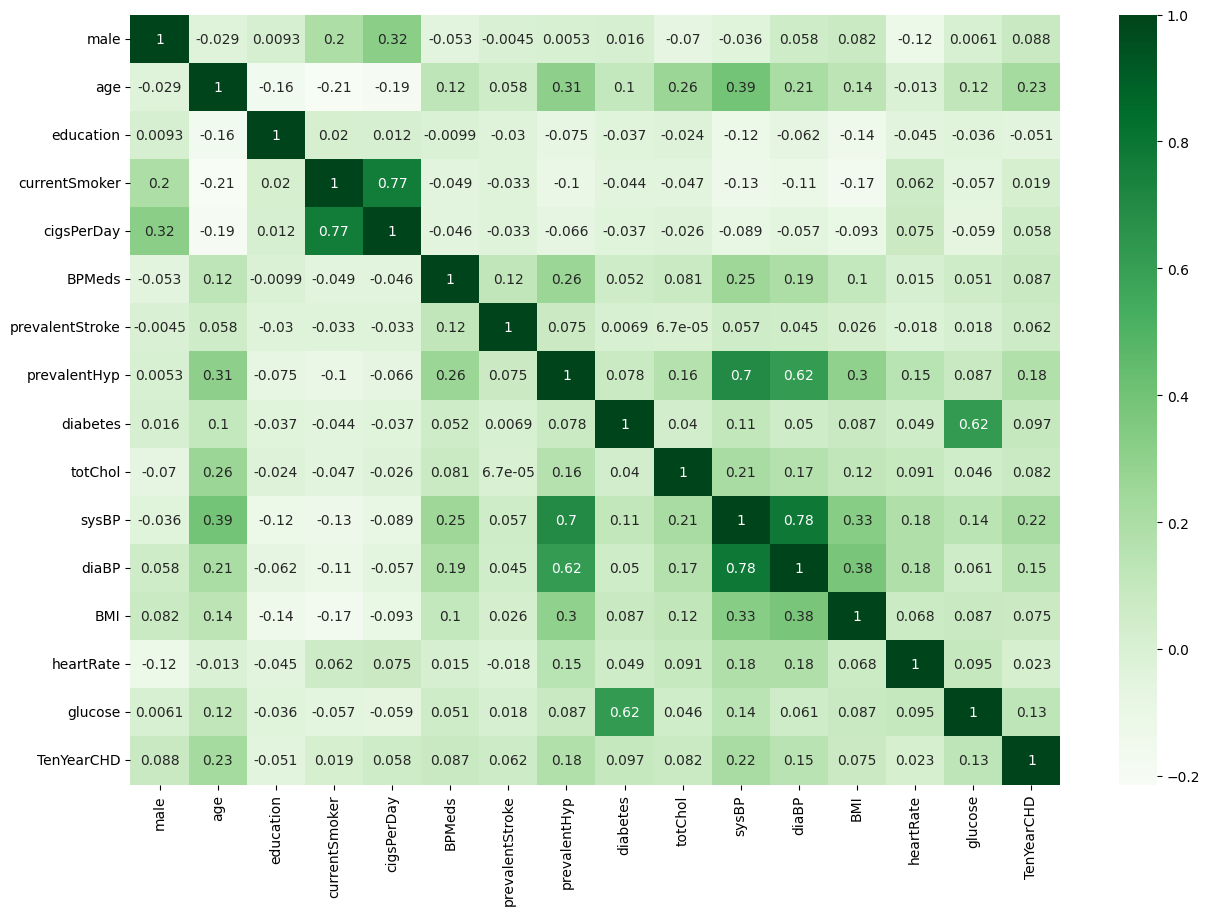

In [9]:
corr = data.corr()
fig , ax = plt.subplots(figsize=(15 , 10))
sns.heatmap(corr ,annot= True , ax=ax , cmap= 'Greens');

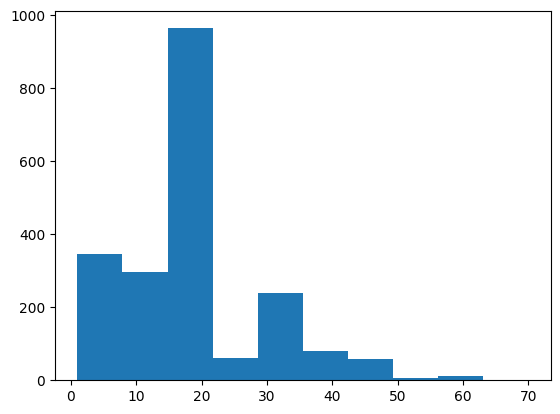

In [10]:
plt.hist(x=data[data.currentSmoker == 1].cigsPerDay, bins=10)
plt.show()

In [11]:
data.currentSmoker.value_counts()

,count
currentSmoker,
0,2144
1,2094


In [12]:
data[(data.currentSmoker == 1) & (data.cigsPerDay.isna())]

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
131,1,43,4.0,1,NaN,0.0,0,0,0,222.0,109.5,69.0,25.50,75.0,NaN,0
139,1,49,4.0,1,NaN,0.0,0,0,0,256.0,127.5,81.5,28.21,93.0,85.0,1
1046,0,49,1.0,1,NaN,0.0,0,0,0,280.0,120.0,80.0,22.33,90.0,75.0,0
1292,1,42,3.0,1,NaN,0.0,0,0,0,225.0,122.5,80.0,25.54,90.0,90.0,0
1347,0,58,4.0,1,NaN,0.0,0,1,0,270.0,195.0,117.5,23.35,75.0,NaN,0
1451,1,54,1.0,1,NaN,0.0,0,0,0,219.0,110.0,72.0,26.05,95.0,86.0,0
1497,1,55,1.0,1,NaN,0.0,0,0,0,214.0,132.5,85.5,29.25,70.0,103.0,0
1610,0,61,1.0,1,NaN,0.0,0,1,0,356.0,168.0,98.0,27.30,103.0,106.0,0
1625,0,49,2.0,1,NaN,0.0,0,1,0,233.0,158.0,102.0,25.31,90.0,72.0,0
1870,0,47,2.0,1,NaN,0.0,0,0,0,365.0,127.0,76.0,24.44,72.0,80.0,0


In [13]:
currSmoker_nullidx = data[(data.currentSmoker == 1) & (data.cigsPerDay.isna())].index

In [14]:
data[data.currentSmoker == 1].cigsPerDay.median()

20.0

In [15]:
data.loc[currSmoker_nullidx, 'cigsPerDay'] = data[data.currentSmoker == 1].cigsPerDay.median()

In [16]:
data.loc[currSmoker_nullidx, 'cigsPerDay']

,cigsPerDay
131,20.0
139,20.0
1046,20.0
1292,20.0
1347,20.0
1451,20.0
1497,20.0
1610,20.0
1625,20.0
1870,20.0


In [17]:
data.isna().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [18]:
data.BPMeds.value_counts()

,count
BPMeds,
0.0,4061
1.0,124


In [19]:
data.BPMeds = data.BPMeds.fillna(value=2)

In [20]:
data[data.prevalentHyp == 1].totChol.describe()

,totChol
count,1301.000000
mean,247.613374
std,47.698109
min,107.000000
25%,216.000000
50%,245.000000
75%,273.000000
max,696.000000


In [21]:
data[data.prevalentHyp == 0].totChol.describe()

,totChol
count,2887.000000
mean,231.813301
std,42.216280
min,113.000000
25%,202.000000
50%,229.000000
75%,258.000000
max,464.000000


In [22]:
medians = data.groupby('prevalentHyp')['totChol'].median()

In [ ]:
medians

,totChol
prevalentHyp,
0,229.0
1,245.0


In [23]:
def replace_null_with_median(row, medians, numerical_col, categorical_col):
  if pd.isnull(row[numerical_col]):
    return medians[row[categorical_col]]
  else:
    return row[numerical_col]

In [24]:

data.totChol = data.apply(lambda row : replace_null_with_median(row, medians, 'totChol', 'prevalentHyp'), axis=1)

In [25]:

data.isna().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [26]:
data[data.prevalentHyp == 0].BMI.describe()

,BMI
count,2910.000000
mean,24.977550
std,3.537185
min,15.540000
25%,22.540000
50%,24.680000
75%,27.140000
max,44.270000


In [27]:
data[data.prevalentHyp == 1].BMI.describe()

,BMI
count,1309.000000
mean,27.634836
std,4.580788
min,15.960000
25%,24.650000
50%,27.010000
75%,29.820000
max,56.800000


In [28]:
medians_BMI = data.groupby('prevalentHyp')['BMI'].median()

In [29]:
data.BMI = data.apply(lambda row : replace_null_with_median(row, medians_BMI, 'BMI', 'prevalentHyp'), axis=1)

In [30]:
data[data.heartRate.isna()]

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
689,1,64,1.0,1,18.0,0.0,0,1,0,219.0,172.5,75.0,29.29,NaN,91.0,1


In [31]:
data.heartRate.median()

75.0

In [32]:
data.loc[data[data.heartRate.isna()].index, 'heartRate'] = data.heartRate.median()

In [33]:

median_diabetes = medians_BMI = data.groupby('diabetes')['glucose'].median()

In [34]:
median_diabetes

,glucose
diabetes,
0,78.0
1,145.0


In [35]:
data.glucose = data.apply(lambda row : replace_null_with_median(row, median_diabetes, 'glucose', 'diabetes'), axis=1)

In [36]:
data.isna().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


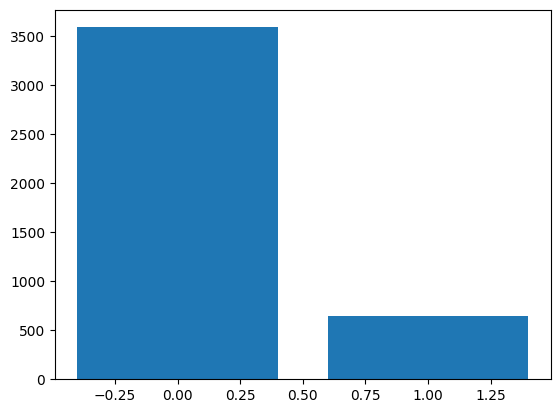

In [37]:
plt.bar(data.TenYearCHD.value_counts().index, data.TenYearCHD.value_counts().values)
plt.show()
## Setul de date este imbalansat

In [38]:
data

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,2.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0


In [39]:
import itertools
import torch, torch.nn as nn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

torch.manual_seed(42); np.random.seed(42)

# ---- data ----------------------------------------------------------------
X = data.drop(columns="TenYearCHD").values.astype(np.float32)
y = data["TenYearCHD"].values.astype(np.float32)

# ---- model + training ----------------------------------------------------
def make_model(n_in, hidden, dropout):
    layers, prev = [], n_in
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
        prev = h
    return nn.Sequential(*layers, nn.Linear(prev, 1), nn.Flatten(0))

def fit(Xtr, ytr, hidden, dropout, lr, epochs=50, bs=64):
    torch.manual_seed(42)
    model = make_model(Xtr.shape[1], hidden, dropout)
    # pos_weight handles the ~15% class imbalance
    pw = torch.tensor((len(ytr) - ytr.sum()) / ytr.sum())
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xt, yt = torch.tensor(Xtr), torch.tensor(ytr)

    model.train()
    for _ in range(epochs):
        for i in torch.randperm(len(Xt)).split(bs):
            opt.zero_grad()
            loss_fn(model(Xt[i]), yt[i]).backward()
            opt.step()
    return model

def predict(model, X):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(X))).numpy()

# ---- grid search (folosim AUC ca metrica, accuratetea nu este precisa pentru seturi de date imbalansate----
grid = list(itertools.product([(32,), (64, 32), (128, 64)], [0.2, 0.4], [1e-3, 5e-4]))
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)

scores = []
for hidden, dropout, lr in grid:
    aucs = []
    for tr, va in StratifiedKFold(3, shuffle=True, random_state=42).split(Xtr, ytr):
        sc = StandardScaler().fit(Xtr[tr])          # fit per fold: no leakage
        m = fit(sc.transform(Xtr[tr]).astype(np.float32), ytr[tr], hidden, dropout, lr)
        aucs.append(roc_auc_score(ytr[va], predict(m, sc.transform(Xtr[va]).astype(np.float32))))
    scores.append(np.mean(aucs))
    print(f"AUC {scores[-1]:.4f}  hidden={hidden} dropout={dropout} lr={lr}")

hidden, dropout, lr = grid[int(np.argmax(scores))]
print(f"\nBest: hidden={hidden} dropout={dropout} lr={lr}  (CV AUC {max(scores):.4f})")

# ---- refit on all training data + evaluate -------------------------------
sc = StandardScaler().fit(Xtr)
model = fit(sc.transform(Xtr).astype(np.float32), ytr, hidden, dropout, lr)
probs = predict(model, sc.transform(Xte).astype(np.float32))
pred = (probs >= .5).astype(int)

print(f"\nTest AUC: {roc_auc_score(yte, probs):.4f}")
print(confusion_matrix(yte, pred))
print(classification_report(yte, pred, digits=3))

AUC 0.7370  hidden=(32,) dropout=0.2 lr=0.001
AUC 0.7373  hidden=(32,) dropout=0.2 lr=0.0005
AUC 0.7383  hidden=(32,) dropout=0.4 lr=0.001
AUC 0.7375  hidden=(32,) dropout=0.4 lr=0.0005
AUC 0.7131  hidden=(64, 32) dropout=0.2 lr=0.001
AUC 0.7262  hidden=(64, 32) dropout=0.2 lr=0.0005
AUC 0.7284  hidden=(64, 32) dropout=0.4 lr=0.001
AUC 0.7338  hidden=(64, 32) dropout=0.4 lr=0.0005
AUC 0.6895  hidden=(128, 64) dropout=0.2 lr=0.001
AUC 0.7124  hidden=(128, 64) dropout=0.2 lr=0.0005
AUC 0.7158  hidden=(128, 64) dropout=0.4 lr=0.001
AUC 0.7307  hidden=(128, 64) dropout=0.4 lr=0.0005

Best: hidden=(32,) dropout=0.4 lr=0.001  (CV AUC 0.7383)

Test AUC: 0.6872
[[485 234]
 [ 55  74]]
              precision    recall  f1-score   support

         0.0      0.898     0.675     0.770       719
         1.0      0.240     0.574     0.339       129

    accuracy                          0.659       848
   macro avg      0.569     0.624     0.555       848
weighted avg      0.798     0.659     0.705